In [1]:
import pandas as pd

# Load dataset
file_path = "https://gitlab.crio.do/me_notebook/me_jupyter_airbnbanalysis/-/raw/master/Airbnb_data.csv"
df = pd.read_csv(file_path)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [6]:
# Fill missing values where necessary
df["reviews_per_month"].fillna(0, inplace=True)  # Replace NaNs with 0 for review counts
df.drop(columns=["last_review"], inplace=True)  # Drop last_review since it is not needed
# Replace only missing values in 'name' and 'host_name' with 'unknown'
df["name"].fillna("unknown", inplace=True)
df["host_name"].fillna("unknown", inplace=True)

In [7]:
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


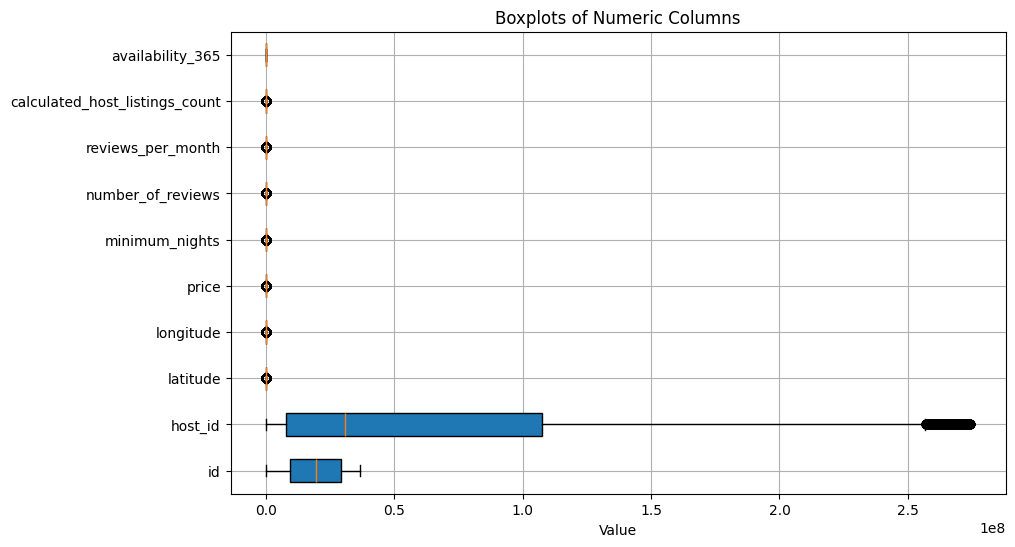

In [14]:
# Selecting only numeric columns
!pip install matplotlib
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(10, 6))
plt.boxplot(df[numeric_columns], vert=False, patch_artist=True)
plt.title("Boxplots of Numeric Columns")
plt.xlabel("Value")
plt.yticks(range(1, len(numeric_columns) + 1), numeric_columns)
plt.grid(True)
plt.show()


In [15]:
# Ensure data types are correct
df["price"] = pd.to_numeric(df["price"], errors='coerce')
df["availability_365"] = pd.to_numeric(df["availability_365"], errors='coerce')

In [16]:
# Remove outliers (if necessary)
df = df[df["price"] > 0]  # Remove listings with zero or negative price
df = df[df["minimum_nights"] < 365]  # Remove extreme long-term stays

In [17]:

import numpy as np

Q1 = df["number_of_reviews"].quantile(0.25)  # First quartile
Q3 = df["number_of_reviews"].quantile(0.75)  # Third quartile
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


# Cap outliers at threshold values
df["number_of_reviews"] = np.where(df["number_of_reviews"] < lower_bound, lower_bound, df["number_of_reviews"])
df["number_of_reviews"] = np.where(df["number_of_reviews"] > upper_bound, upper_bound, df["number_of_reviews"])

In [18]:
import numpy as np

Q1 = df["price"].quantile(0.25)  # First quartile
Q3 = df["price"].quantile(0.75)  # Third quartile
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


# Cap outliers at threshold values
df["price"] = np.where(df["price"] < lower_bound, lower_bound, df["price"])
df["price"] = np.where(df["price"] > upper_bound, upper_bound, df["price"])

<Figure size 1200x600 with 0 Axes>

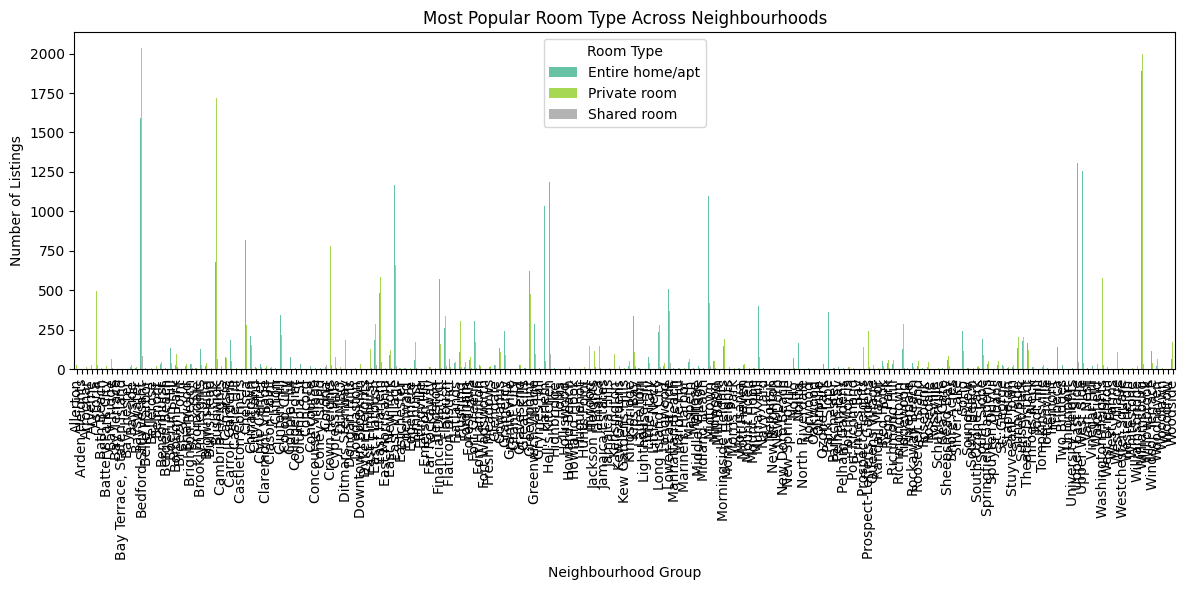

In [19]:

grouped = df.groupby(['neighbourhood','room_type']).size().unstack()

grouped.fillna(0,inplace=True)

# Create bar plot
plt.figure(figsize=(12, 6))
grouped.plot(kind='bar', colormap='Set2', figsize=(12, 6))

# Add plot details
plt.title('Most Popular Room Type Across Neighbourhoods')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.legend(title='Room Type')
plt.tight_layout()

# Display the plot
plt.show()


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\pc\AppData\Local\Temp\ipykernel_17448\1916841733.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['neighbourhood_group', 'price_range']).size().unstack()


<Figure size 1200x600 with 0 Axes>

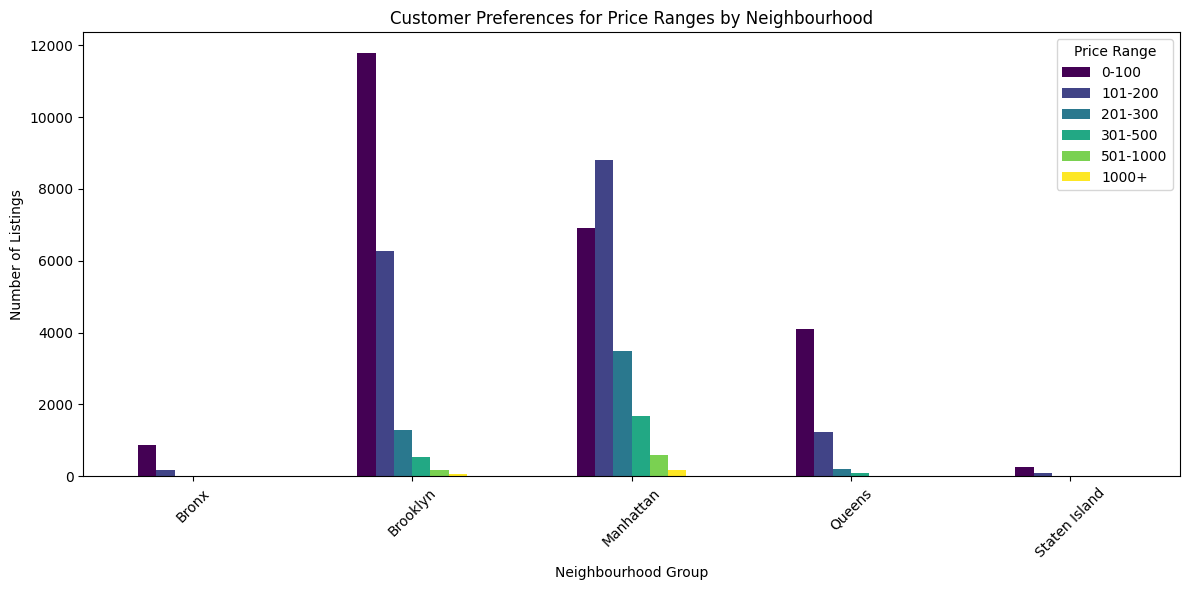

In [22]:

import pandas as pd
import matplotlib.pyplot as plt
!pip install seaborn
import seaborn as sns

# Load data
file_path = "https://gitlab.crio.do/me_notebook/me_jupyter_airbnbanalysis/-/raw/master/Airbnb_data.csv"
df = pd.read_csv(file_path)

# 1. Create a new column 'price_range' using pd.cut()
price_bins = [0, 100, 200, 300, 500, 1000, df['price'].max()]
price_labels = ['0-100', '101-200', '201-300', '301-500', '501-1000', '1000+']

df['price_range'] = pd.cut(df['price'], bins=price_bins, labels=price_labels, include_lowest=True)

# 2. Group by 'neighbourhood_group' and 'price_range', count listings, and reshape
grouped = df.groupby(['neighbourhood_group', 'price_range']).size().unstack()

# 3. Fill missing values with 0
grouped.fillna(0, inplace=True)

# 4. Generate the bar plot
plt.figure(figsize=(12, 6))
grouped.plot(kind='bar', colormap='viridis', figsize=(12, 6))

# Plot enhancements
plt.title('Customer Preferences for Price Ranges by Neighbourhood')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.legend(title='Price Range')
plt.tight_layout()

# Display the plot
plt.show()

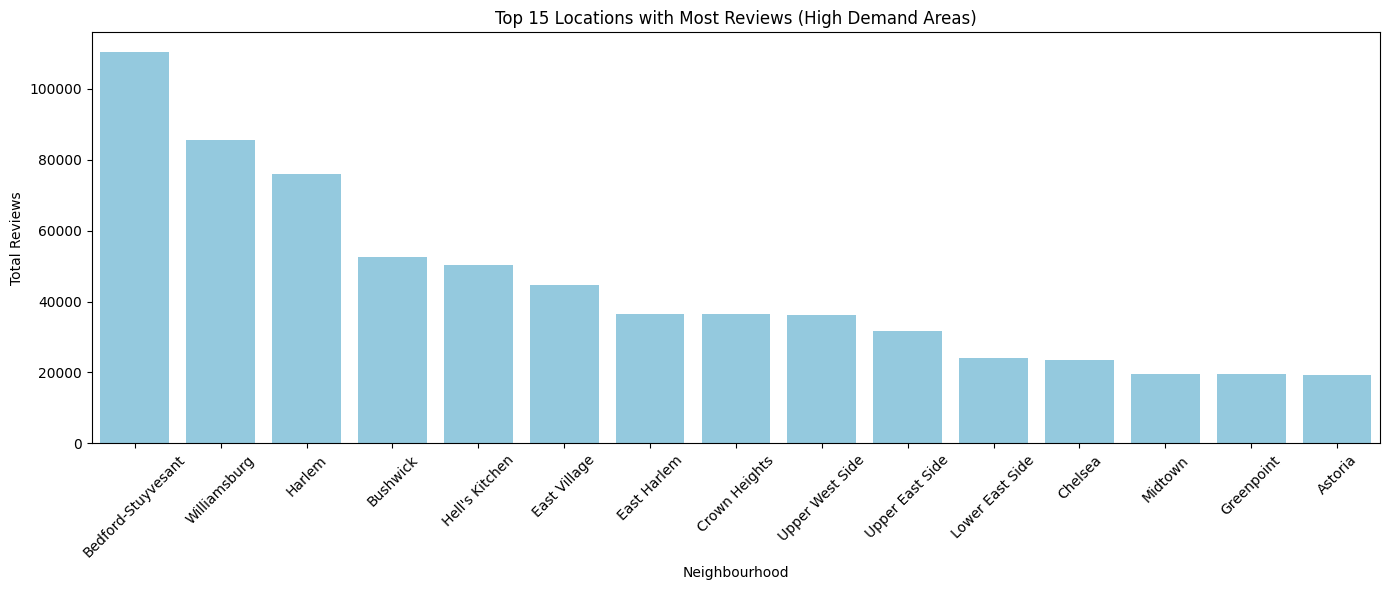

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
file_path = "https://gitlab.crio.do/me_notebook/me_jupyter_airbnbanalysis/-/raw/master/Airbnb_data.csv"
df = pd.read_csv(file_path)

# 1. Group by 'neighbourhood' and sum 'number_of_reviews'
neighbourhood_reviews = df.groupby('neighbourhood')['number_of_reviews'].sum()

# 2. Sort in descending order and get top 15
top15_neighbourhoods = neighbourhood_reviews.sort_values(ascending=False).head(15)

# 3. Create bar plot
plt.figure(figsize=(14, 6))
sns.barplot(x=top15_neighbourhoods.index, y=top15_neighbourhoods.values, color='skyblue')

# Plot enhancements
plt.title('Top 15 Locations with Most Reviews (High Demand Areas)')
plt.xlabel('Neighbourhood')
plt.ylabel('Total Reviews')
plt.xticks(rotation=45)
plt.tight_layout()

# Show plot
plt.show()

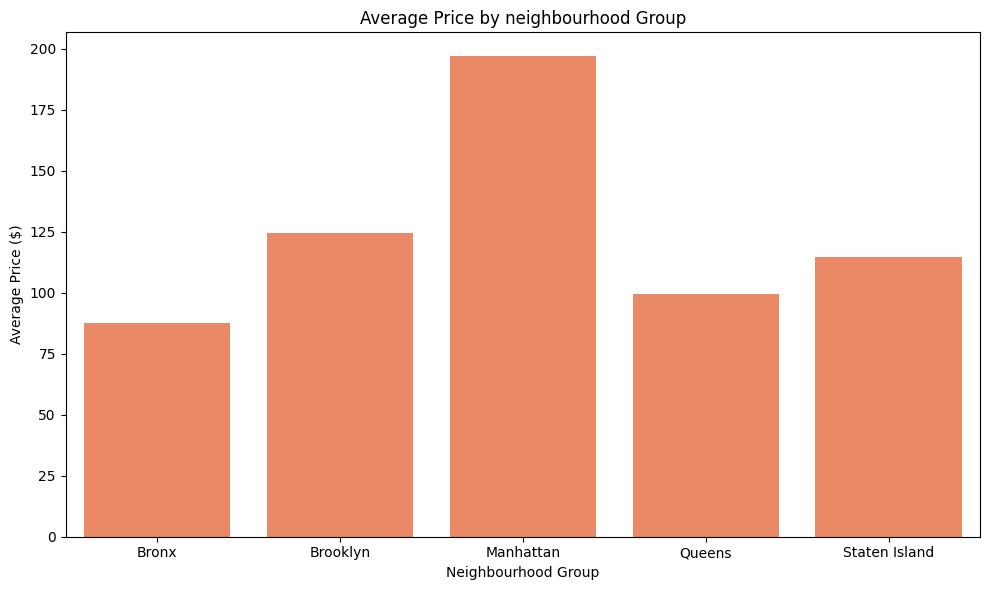

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pricing Strategy Analysis

# TODO:
# 1. Group the data by 'neighbourhood_group' and calculate the average price.
# 2. Reset the index to prepare for plotting.
# 3. Create a bar plot showing average price per neighborhood group:
#    - Use a distinct color for the bars.
#    - Add a title and axis labels.
#    - Display the plot.

avg_price = df.groupby('neighbourhood_group')['price'].mean()

# 2. Reset index for plotting
avg_price = avg_price.reset_index()

# 3. Create bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_price, x='neighbourhood_group', y='price', color='coral')

# Plot enhancements
plt.title('Average Price by neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Price ($)')
plt.tight_layout()

# Show the plot
plt.show()

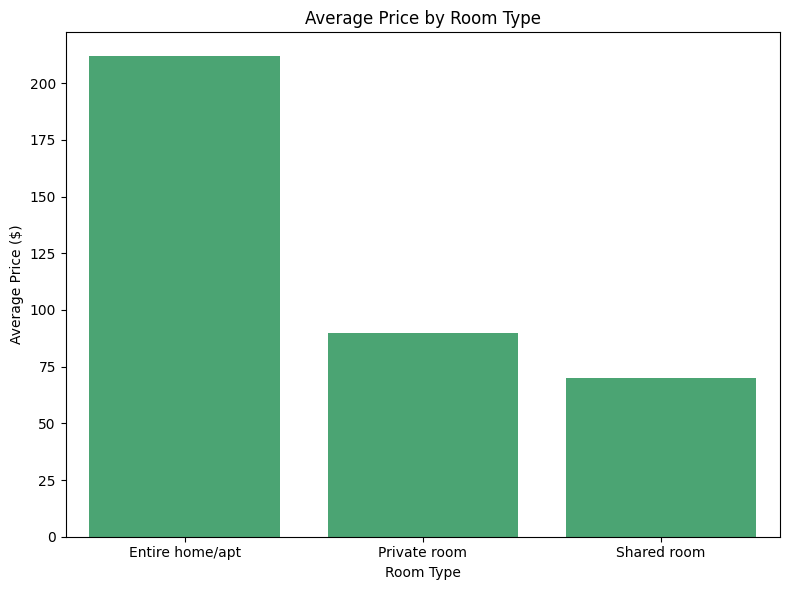

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = "https://gitlab.crio.do/me_notebook/me_jupyter_airbnbanalysis/-/raw/master/Airbnb_data.csv"
df = pd.read_csv(file_path)

# 1. Group by 'room_type' and calculate average price
avg_price_by_room = df.groupby('room_type')['price'].mean()

# 2. Reset index
avg_price_by_room = avg_price_by_room.reset_index()

# 3. Create bar plot
plt.figure(figsize=(8, 6))
sns.barplot(data=avg_price_by_room, x='room_type', y='price', color='mediumseagreen')

# Add title and axis labels
plt.title('Average Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Price ($)')
plt.tight_layout()

# Show plot
plt.show()

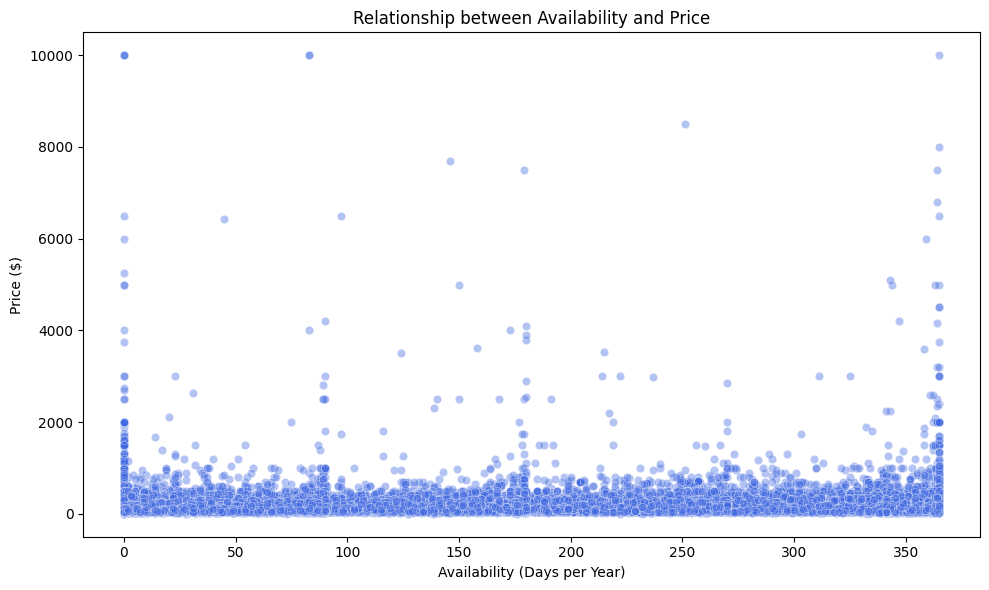

In [26]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = "https://gitlab.crio.do/me_notebook/me_jupyter_airbnbanalysis/-/raw/master/Airbnb_data.csv"
df = pd.read_csv(file_path)

# 1. Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='availability_365', y='price', alpha=0.4, color='royalblue')

# 2. Add title and axis labels
plt.title('Relationship between Availability and Price')
plt.xlabel('Availability (Days per Year)')
plt.ylabel('Price ($)')

# 3. Show the plot
plt.tight_layout()
plt.show()

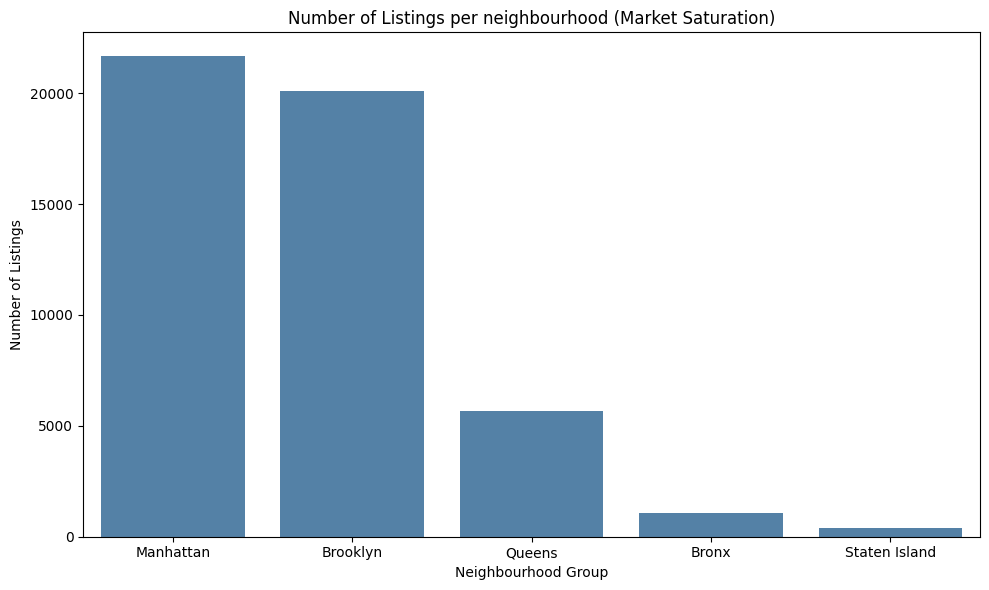

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Market Competition & Growth Opportunities

# TODO:
# 1. Count the number of listings per 'neighbourhood_group' to assess market saturation.
# 2. Reset the index and rename columns for clarity.
# 3. Create a bar plot to visualize the number of listings per neighborhood group:
#    - Set figure size and choose a distinct bar color.
#    - Rotate x-axis labels for better readability.
#    - Add title and axis labels.
#    - Display the plot.

file_path = "https://gitlab.crio.do/me_notebook/me_jupyter_airbnbanalysis/-/raw/master/Airbnb_data.csv"
df = pd.read_csv(file_path)

# 1. Count number of listings per neighbourhood group
listing_counts = df['neighbourhood_group'].value_counts().reset_index()

# 2. Rename columns for clarity
listing_counts.columns = ['neighbourhood_group', 'listing_count']

# 3. Create bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=listing_counts, x='neighbourhood_group', y='listing_count', color='steelblue')

# Add plot labels and title
plt.title('Number of Listings per neighbourhood (Market Saturation)')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.tight_layout()

# Display the plot
plt.show()

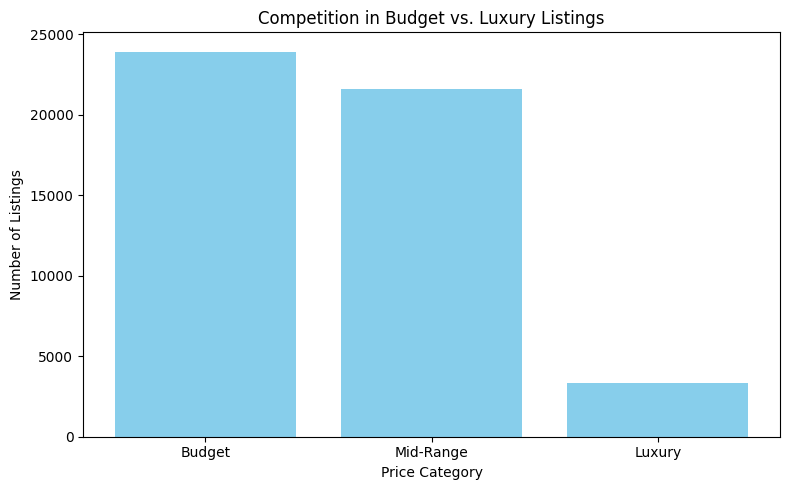

In [28]:
# TODO:
# 1. Create a new column 'price_category' by binning the 'price' into defined categories (e.g., Budget, Luxury).
# 2. Count the number of listings in each price category to understand market competition.
# 3. Rename the resulting columns for clarity.
# 4. Create a bar plot to visualize the distribution of listings across price categories:
#    - Set figure size and bar color.
#    - Rotate x-axis labels for readability.
#    - Add title and axis labels.
#    - Display the plot.
import pandas as pd
import matplotlib.pyplot as plt

# Sample data (replace with your actual DataFrame)
# df = pd.read_csv("your_dataset.csv")

# Step 1: Create a new column 'price_category'
bins = [0, 100, 300, float('inf')]
labels = ['Budget', 'Mid-Range', 'Luxury']
df['price_category'] = pd.cut(df['price'], bins=bins, labels=labels)

# Step 2: Count the number of listings in each price category
price_counts = df['price_category'].value_counts().reset_index()

# Step 3: Rename columns for clarity
price_counts.columns = ['Price Category', 'Listing Count']

# Step 4: Create a bar plot
plt.figure(figsize=(8, 5))
plt.bar(price_counts['Price Category'], price_counts['Listing Count'], color='skyblue')

# Formatting
plt.title('Competition in Budget vs. Luxury Listings')
plt.xlabel('Price Category')
plt.ylabel('Number of Listings')

# Display the plot
plt.tight_layout()
plt.show()

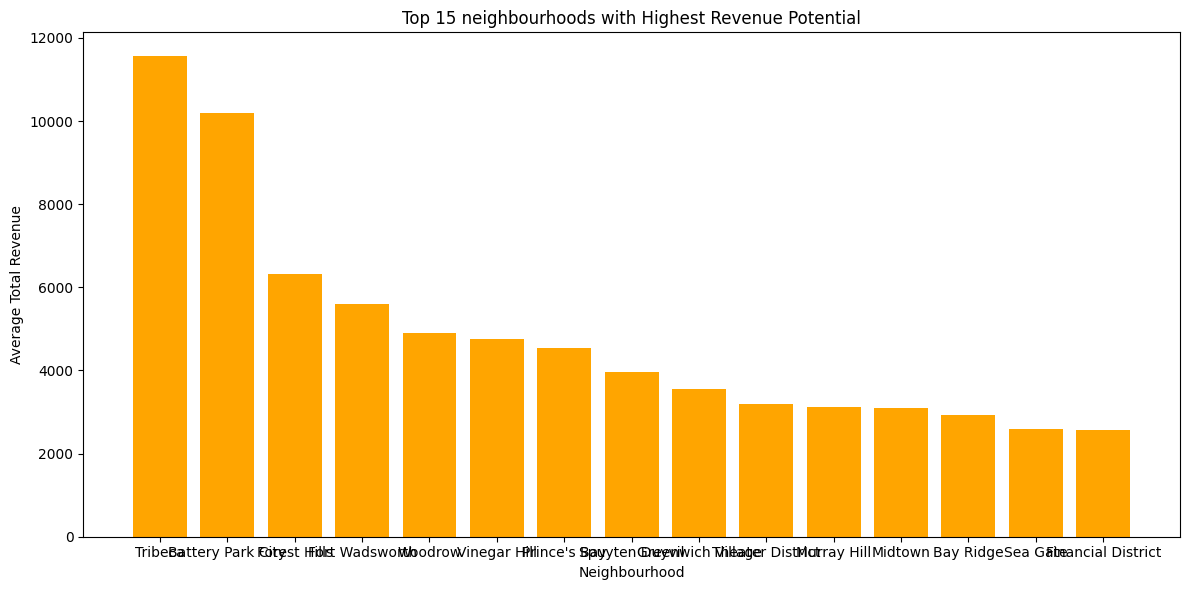

In [29]:
# TODO:
# 1. Create a new column 'total_revenue' by multiplying 'price' with 'minimum_nights'.
# 2. Group data by 'neighbourhood' and calculate average total revenue to estimate potential earnings.
# 3. Sort the neighborhoods by revenue potential in descending order.
# 4. Create a bar plot for the top 15 neighborhoods with the highest average revenue:
#    - Set figure size and bar color.
#    - Rotate x-axis labels for readability.
#    - Add title and axis labels.
#    - Display the plot.

import pandas as pd
import matplotlib.pyplot as plt

# Sample data loading (replace with your dataset if needed)
# df = pd.read_csv("your_dataset.csv")

# Step 1: Create a new column 'total_revenue'
df['total_revenue'] = df['price'] * df['minimum_nights']

# Step 2: Group by 'neighbourhood' and calculate average total revenue
avg_revenue_by_neighbourhood = df.groupby('neighbourhood')['total_revenue'].mean().reset_index()

# Step 3: Sort neighborhoods by revenue potential in descending order
avg_revenue_sorted = avg_revenue_by_neighbourhood.sort_values(by='total_revenue', ascending=False)

# Step 4: Create a bar plot for the top 15 neighborhoods
top_15 = avg_revenue_sorted.head(15)

plt.figure(figsize=(12, 6))
plt.bar(top_15['neighbourhood'], top_15['total_revenue'], color='orange')

# Formatting
plt.title('Top 15 neighbourhoods with Highest Revenue Potential')
plt.xlabel('Neighbourhood')
plt.ylabel('Average Total Revenue')

plt.tight_layout()
plt.show()